# **Assignment: Introduction to projective geometry**

Jesús David Petro Ramos - T00065696 \
Aliveette Zambrano Mercado - T00067935 \
Universidad Tecnológica de Bolívar

Link del repo donde he estado realizando la actividad: [Repo](https://github.com/JesusPetro/Vision-Artificial-2P2025/blob/main/semana%204/T00065696_work3.ipynb)
<!-- Based on the jupyter notebook by [Vince Knight](https://github.com/drvinceknight/Python-Mathematics-Handbook) -->


In [1]:
# Importamos las librerias

import os
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from PIL import Image


In [2]:
# Para bajar los archivos desde Github:

def download_file(filename):
    """
    Download a file from the GitHub repository and save it into the ./data/ folder.

    Args:
        filename (str): Name of the file to download.

    Returns:
        str: Local path to the downloaded file.
    """
    
    BASE_URL = 'https://github.com/agmarrugo/computer-vision-utb/blob/main/data/{filename}?raw=true'
    
    os.makedirs('./data/', exist_ok=True)
    output = os.path.join('./data/', filename)

    urllib.request.urlretrieve(BASE_URL.format(filename=filename), output)
    return output


### **Points in Homogeneous Coordinates**

### __Exercise 1__

 What is the 2D Cartesian coordinates of the points with homogeneous coordinates

\begin{align}
\mathbf{x_1} = \left(
\begin{array}{c}
4\\
-2\\
2\\
\end{array}
\right)
,\enspace
\mathbf{x_2} = \left(
\begin{array}{c}
3\\
-2\\
-1\\
\end{array}
\right)
, \enspace \text{and }
\mathbf{x_3} = \left(
\begin{array}{c}
4\lambda\\
-2\lambda\\
2\lambda\\
\end{array}
\right)
,\enspace
\lambda \neq 0?
\end{align}

What is the interpretation of the point with homogeneous coordinates

\begin{align}
\mathbf{x_4} = \left(
\begin{array}{c}
4\\
-2\\
0\\
\end{array}
\right)
\enspace?
\end{align}

### **Answer**


<div
  style="border-left: 4px solid rgb(23, 146, 153); background-color: rgba(23, 146, 153, 0.1); padding: 0.5em; border-radius: 6px;"
>
  <strong style="color: rgb(23, 146, 153);">
    <svg
      xmlns="http://www.w3.org/2000/svg"
      width="15"
      height="15"
      viewBox="0 0 24 24"
      fill="none"
      stroke="currentColor"
      stroke-width="2"
      stroke-linecap="round"
      stroke-linejoin="round"
      style="vertical-align: -1px; margin-right: 4px;"
    >
      <circle cx="12" cy="12" r="10" />
      <path d="M12 16v-4" />
      <path d="M12 8h.01" /></svg
    >Info </strong
  ><br />
  <span style="color: black;">Para pasar de coordenadas homogéneas a cartesianas se hace de la siguiente forma </span>
</div>



$$

\begin{align}
\mathbf{x_n} = 
\left(
\begin{array}{c}
x\\
y\\
w\\
\end{array}
\right)
\Rightarrow

\left(
\begin{array}{c}
x/w\\
y/w\\
1\\
\end{array}
\right)

\Rightarrow
\left( \frac{x}{w}, \frac{y}{w} \right)
, \enspace
w \neq 0
\end{align}

$$

__Con las coordenadas anteriores:__
$$
\mathbf{x_1} = 
\left(
\begin{array}{c}
4/2\\
-2/2\\
2/2\\
\end{array}
\right)
\Rightarrow

\left(2, -1 \right)
$$

$$
\mathbf{x_2} = 
\left(
\begin{array}{c}
3/-1\\
-2/-1\\
-1/-1\\
\end{array}
\right)
\Rightarrow

\left(-3, 2 \right)
$$

$$
\mathbf{x_3} = 
\left(
\begin{array}{c}
4\lambda/2\lambda\\
-2\lambda/2\lambda\\
2\lambda/2\lambda\\
\end{array}
\right)
\Rightarrow

\left(2, -1 \right)
$$



Todo esto es siempre y cuando $w \neq 0$. ¿Qué pasa cuando $w = 0$? En este caso, lo que normalmente se hace es tomar las coordenadas como $\infty$, aunque todo depende del contexto. Si se está trabajando con intersecciones de líneas (paralelas), por ejemplo, puede significar que no hay intersección o que hay infinitas.

Como lo es en el caso de 

$$
\begin{align}
\mathbf{x_4} = \left(
\begin{array}{c}
4\\
-2\\
0\\
\end{array}
\right)
\enspace
\end{align}
$$


### __Computer Exercise 1.__
Write a Python function `pflat` that divides the homogeneous coordinates with their last entry for points of any dimensionality. (You may assume that none of the points have last homogeneous coordinate zero.) Apply the function to the points in `x2D` and `x3D` in the file `compEx1.npz`, and plot the result.

In [3]:
# importamos el archivo compEx1.npz del Github del profesor Marrugo

filename = 'compEx1.npz'
path_file = download_file(filename)

data = np.load(path_file)

x2D = data['x2D']
x3D = data['x3D']

In [4]:
def pflat(hx):
  ''' pflat - Normalizes array of homogeneous coordinates (2D or 3D) and converts
      to cartesian (inhomogeneous) coordinates.

      Usage:  x = pflat(hx)
      Argument:
          hx  - an N x npts array of homogeneous coordinates.
      Returns:
          x - an (N-1) x npts array of cartesian (inhomogeneous) coordinates
  '''
  return hx[:-1] / hx[-1]

x2Dn = pflat(x2D)
x3Dn = pflat(x3D)

print(f'x2D shape Before: {x2D.shape}, x2Dn shape After: {x2Dn.shape}')
print(f'x3D shape Before: {x3D.shape}, x3Dn shape After: {x3Dn.shape}')


x2D shape Before: (3, 63), x2Dn shape After: (2, 63)
x3D shape Before: (4, 441), x3Dn shape After: (3, 441)


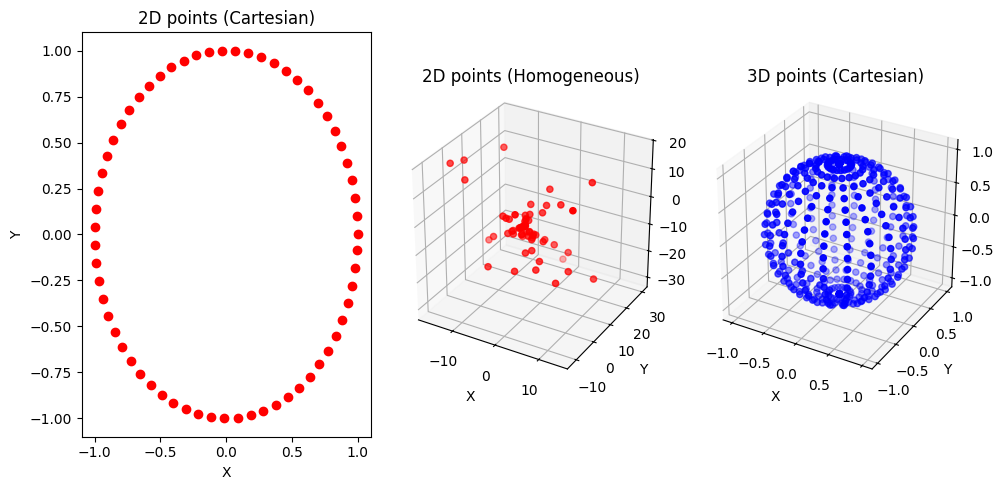

In [5]:
fig = plt.figure(figsize=(10, 5))

ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(*x2Dn, c='r', marker='o')

ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.scatter(*x2D, c='r', marker='o')

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.scatter(*x3Dn, c='b', marker='o')

titles = ["2D points (Cartesian)", "2D points (Homogeneous)", "3D points (Cartesian)"]
axes = [ax1, ax2, ax3]
for title, ax in (zip(titles, axes)):
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    try:
        ax.set_zlabel('Z')
        ax.set_box_aspect([1, 1, 1])
    except AttributeError:
        pass

fig.tight_layout()
plt.show()

### __Exercise 2__

Compute the homogeneous coordinates of the intersection (in $\mathbb{P}^2$) of the lines

\begin{align}
l_1 = \left(
\begin{array}{c}
1\\
1\\
1\\
\end{array}
\right)
, \enspace \text{and }
l_2 = \left(
\begin{array}{c}
3\\
2\\
1\\
\end{array}
\right)
.\enspace
\end{align}

What is the corresponding point in $\mathbb{R}^2$?

Compute the intersection (in $\mathbb{P}^2$) of the lines

\begin{align}
l_3 = \left(
\begin{array}{c}
1\\
2\\
3\\
\end{array}
\right)
, \enspace \text{and }
l_4 = \left(
\begin{array}{c}
1\\
2\\
1\\
\end{array}
\right)
.\enspace
\end{align}

what is the geometric interpretation in $\mathbb{R}^2$?

Compute the line that goes through the points with Cartesian coordinates

\begin{align}
x_1 = \left(
\begin{array}{c}
1\\
1\\
\end{array}
\right)
, \enspace \text{and }
x_2 = \left(
\begin{array}{c}
3\\
2\\
\end{array}
\right)
.\enspace
\end{align}

### __Answer__

__1.__
Sea una recta en coordenadas homogéneas $l=[a,b,c]^T$, que representa $ax+by+c=0$.
La intersección de dos rectas $l_i, l_j$ en $\mathbb{P}^2$ se obtiene con el **producto cruz**:
$$
\mathbf{q}_{ij}=l_i \times l_j.
$$ 


teniendo en cuenta lo anterior y las lineas $l_1$ y $l_2$, la intercepción se obtiene de la siguiente manera: 

$$

\mathbf{q_{12}} = 

\left(
    \begin{array}{c}
    1\\
    1\\
    1\\
    \end{array}
\right)

\times

\left(
    \begin{array}{c}
    3\\
    2\\
    1\\
    \end{array}
\right)
= 
\enspace

\left|
    \begin{array}{c}
        \hat{\textbf{i}} & \hat{\textbf{j}} & \hat{\textbf{k}} \\
        1 & 1 & 1 \\
        3 & 2 & 1 \\
    \end{array}
\right|

= 

\left(
    \begin{array}{c}
    -1 \\
    ­­ 2 \\
    -1 \\
    \end{array}
\right)

$$


$$
en \space \mathbb{P}^2: (-1, 2, -1)^T \sim (1, -2, 1)^T
$$

Punto correspondiente en $\mathbb{R}^2$: Teniendo en cuenta el punto anterior de coordenadas homogéneas a cartesianas, dividimos todo el vector entre $w$, para obtener el punto resultante, el cual es: 

$$
R_1 = 
\left(
    \begin{array}{c}
        1 & -2 \\
    \end{array}
\right)
$$


__2.__
para $l_3$ y $l_4$ se harán los mismos pasos que en el ejercicio anterior: 

$$

\mathbf{q_{12}} = 

\left(
    \begin{array}{c}
    1\\
    2\\
    3\\
    \end{array}
\right)

\times

\left(
    \begin{array}{c}
    1\\
    2\\
    1\\
    \end{array}
\right)
= 
\enspace

\left|
    \begin{array}{c}
        \hat{\textbf{i}} & \hat{\textbf{j}} & \hat{\textbf{k}} \\
        1 & 2 & 3 \\
        1 & 2 & 1 \\
    \end{array}
\right|

= 

\left(
    \begin{array}{c}
    -4 \\
    2 \\
    0 \\
    \end{array}
\right)

$$


$$
en \space \mathbb{P}^2: (-4, 2, 0)^T
$$


En esta ocasión, la tercera coordenada $w$ del punto de intesección es 0. Por tanto, no puede convertirse a coordenadas cartesianas: Se trata de un __punto en el infinito__ que muestra la dirección en la que ambas rectas se extienden. En $\mathbb{R}^2$ esto implica que las rectas son __paralelas__

Aunque este ejercicio fue resuelto de forma metódica, en realidad era posible anticipar el resultado al notar que los vectores normales de ambas rectas son proporcionales: (1,2) y (1,2) coinciden (múltiplo 1), por lo que tienen la misma pendiente y distintos términos independientes. 

Para concluir, las líneas nunca se intersecan, por lo tanto, no es posible encontrar un punto en las coordenadas cartesianas (Para entenderlo de forma visual, revisar la gráfica equivalente al 'punto2')


__3.__
Para encontrar la ecuación de la recta que pasa por estos dos puntos, primero debemos expresar ambos puntos en coordenadas homogéneas. Una vez convertidos, se calcula el producto cruz entre ellos para obtener el vector de la recta en el espacio proyectivo. Este procedimiento garantiza que la recta obtenida pase exactamente por ambos puntos dados.

$$
\mathbf{x_1} = 
\left(
    \begin{array}{c}
    1 \\ 
    1 \\
    \end{array}
\right)
\rightarrow
\mathbf{p_1} = 
\left(
    \begin{array}{c}
    1\\
    1\\
    1\\
    \end{array}
\right)
$$

$$
\mathbf{x_2} = 
\left(
    \begin{array}{c}
    3 \\ 
    2 \\
    \end{array}
\right)
\rightarrow
\mathbf{p_2} = 
\left(
    \begin{array}{c}
    3\\
    2\\
    1\\
    \end{array}
\right)
$$

Teniendo las coordenadas homogéneas, pasamos a realizar el producto cruz:

$$
l_5 = 
\left(
    \begin{array}{c}
    1\\
    1\\
    1\\
    \end{array}
\right)
\times
\left(
    \begin{array}{c}
    3\\
    2\\
    1\\
    \end{array}
\right)
= 
\left(
    \begin{array}{c}
    -1\\
    2\\
    -1\\
    \end{array}
\right)
\sim
\left(
    \begin{array}{c}
    1\\
    -2\\
    1\\
    \end{array}
\right)
$$

Por lo tanto, la ecuación cartesiana de la recta es:

$$ x - 2y + 1 = 0 $$

Al verificar sustituyendo los puntos $(1,1)$ y $(3,2)$ en la ecuación, se comprueba que ambos satisfacen la recta, confirmando que efectivamente pasa por los dos puntos dados.

In [6]:
def line_equation(values: np.ndarray, coef_a: float, coef_b: float, coef_c:float):
    """
    Computes the y-coordinates of a line given multiple x-values and the coefficients of the line equation.

    The line is defined by the equation: ax + by + c = 0.
    By solving for y, we get: y = (-a*x - c) / b.

    Args:
        values (np.ndarray): An array of x-values at which to evaluate the line.
        coef_ax (float): Coefficient 'a' of x in the line equation.
        coef_b (float): Coefficient 'b' of y in the line equation.
        coef_c (float): Constant term 'c' in the line equation.

    Returns:
        np.ndarray: An array of y-values corresponding to the input x-values, which can be used for plotting the line.
    """
    return (-coef_a * values - coef_c) / coef_b


def plot_lines_and_intersection(ax, title, label, l1, l2):
    """
    Plots one or two lines and their intersection point on a given Axes object.

    If the inputs are points (2D), it treats them as points and plots them directly.
    If the inputs are lines (3D homogeneous coordinates), it plots the lines and computes
    their intersection in projective space, marking it on the plot.

    Args:
        ax (matplotlib.axes.Axes): The axes on which to plot.
        title (str): Title of the subplot.
        labels (list of str): Labels for the lines in the legend.
        l1 (np.ndarray): First line (3x1) or point (2x1) in homogeneous coordinates.
        l2 (np.ndarray): Second line (3x1) or point (2x1) in homogeneous coordinates.

    Returns:
        None. Plots directly on the provided axes.
    """

    x_values = np.linspace(-3, 4, 100)

    if len(l1.flatten()) < 3 or len(l2.flatten()) < 3:
        handle2 = ax.scatter(l1[0][0], l1[0][1], c = 'r', label= f'{l1[0]}', marker = 'o', zorder = 5)
        handle3 = ax.scatter(l2[0][0], l2[0][1], c = 'r', label= f'{l2[0]}', marker = 'o', zorder = 5)

        l1 = np.hstack([l1, np.array([[1]])]) 
        l2 = np.hstack([l2, np.array([[1]])]) 

        l1 = np.cross(l1,l2)

    else:
        p12 = np.cross(l1,l2)[0]
        R1 = pflat(p12) 

        handle2, = ax.plot(x_values, line_equation(x_values, *l2.flatten()), label=label[1])
        handle3 = ax.scatter(R1[0], R1[1], color='red', label=f'{R1}', marker = 'o', zorder = 5)

    handle1, = ax.plot(x_values, line_equation(x_values, *l1.flatten()), label=label[0])
    
    ax.set(xlabel='x', ylabel='y', title=f'{title}')
    ax.grid()
    ax.legend(handles = [handle1, handle2, handle3])

C:\Users\Gsus\AppData\Local\Temp\ipykernel_6948\846314631.py:11: RuntimeWarning: divide by zero encountered in divide
  return hx[:-1] / hx[-1]


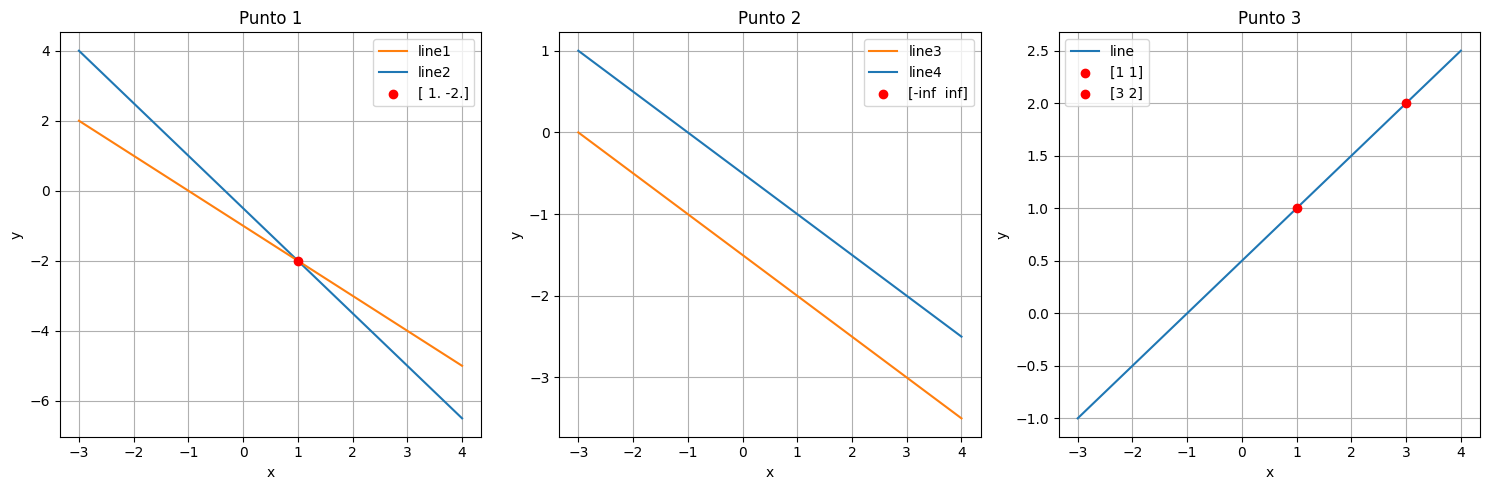

In [7]:
# Código para la visualización del ejercicio anterior
l1 = np.array([[1], [1], [1]]).T
l2 = np.array([[3], [2], [1]]).T

l3 = np.array([[1], [2], [3]]).T
l4 = np.array([[1], [2], [1]]).T

x1 = np.array([[1], [1]]).T
x2 = np.array([[3], [2]]).T

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15, 5))

# Punto 1
plot_lines_and_intersection(ax1, 'Punto 1', ['line1', 'line2'], l1, l2)

#Punto 2
plot_lines_and_intersection(ax2, 'Punto 2', ['line3', 'line4'], l3, l4)

# Punto 3
plot_lines_and_intersection(ax3, 'Punto 3', ['line'], x1, x2)

plt.tight_layout()
plt.show()

### **Computer exercise 2**

Load and plot the image in compEx2.jpg.

In the file `compEx2.npz` there are three pairs of image points. Plot the image points in the same figure as the image.

For each pair of points compute the line going through the points. Use the function `linePoints` to plot the lines in the same image. Do these lines appear to be parallel (in 3D)?

Compute the point of intersection between the second and third line (the lines obtained from the pairs `p2` and `p3`). Plot this point in the same image.

The distance between a 2D-point $x = (x_1, x_2)$ in Cartesian coordinates and a line $l = (a, b, c)$ can be computed using the distance formula

\begin{align}
d = \frac{|ax_1 + bx_2 + c|}{\sqrt{a^2+b^2}}
\end{align}

see your linear algebra book. Compute the distance between the first line and the the intersection point. Is it close to zero? Why/why not?

In [8]:
filename1 = 'compEx2.npz'
filename2 = 'compEx2.JPG'

path_filename1 = download_file(filename1)
path_filename2 = download_file(filename2)

data = np.load(path_filename1)
img = Image.open(path_filename2)
p1, p2, p3 = data['p1'], data['p2'], data['p3']


print(f'{p1.shape = }')
print(f'{p2.shape = }')
print(f'{p3.shape = }')


p1.shape = (3, 2)
p2.shape = (3, 2)
p3.shape = (3, 2)


In [9]:
# Computer Exercise 2 - Solution.

# You will use this function for plotting the lines
def linePoints(line = [0, 0, 0], ref = [-1.,1.]):
    """given a,b,c for straight line as ax+by+c=0,
    return and plot a pair of points based on ref values
    e.g linePoints(-1,1,2) == [[-1.0, -3.0], [1.0, -1.0]]
    """
    a = line[0]
    b = line[1]
    c = line[2]
    if (a==0 and b==0):
      raise Exception("linePoints: a and b cannot both be zero")
    else:
      points = np.array([[-c/a,p] if b==0 else [p,(-c-a*p)/b] for p in ref])
      plt.plot(points[:, 0], points[:, 1])
      return points


def calculate_distance(line, point):
    """Calculate the distance from a point to a line.
    line: [a, b, c] for line ax + by + c = 0
    point: [x, y]
    """
    a = line[0]
    b = line[1]
    c = line[2]
    x = point[0]
    y = point[1]
    return abs(a*x + b*y + c) / np.sqrt(a**2 + b**2)

The distance between x23 and lp1 is 8.26949


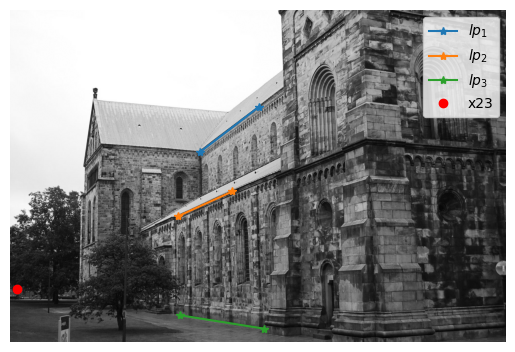

In [10]:


plt.imshow(img, cmap = 'gray')

lp1 = np.cross(p1[:, 0], p1[:, 1])
lp2 = np.cross(p2[:, 0], p2[:, 1])
lp3 = np.cross(p3[:, 0], p3[:, 1])

i = 0
for lp, p in zip((lp1, lp2, lp3), (p1, p2, p3)):
    i += 1
    plt.plot(p[0, :], p[1, :], marker="*", label=f"$lp_{i}$")

# Use np.cross to calculate the intersection x23 of lines lp2 and lp3
x23 = np.cross(lp2, lp3)
x23 = pflat(x23)

# Plot the intersection
plt.plot(x23[0], x23[1], 'ro', label='x23')


d = calculate_distance(lp1, x23)
print(f'The distance between x23 and lp1 is {d:.5f}')

plt.legend()
plt.axis('off')
plt.show()



## __Projective transformations__

### __Exercise 3__

Let $H$ be the projective transformation

\begin{align}
H =
\left(
\begin{array}{ccc}
1 & 1 & 0 \\
0 & 1 & 0 \\
-1 & 0 & 1 \\
\end{array}
\right) \enspace.
\end{align}

Compute the transformations $\mathbf{y_1} \sim H\mathbf{x_1}$ and $\mathbf{y_2} \sim H\mathbf{x_2}$ if

\begin{align}
\mathbf{x_1} = \left(
\begin{array}{c}
1\\
0\\
1\\
\end{array}
\right)
, \enspace \text{and }
\mathbf{x_2} = \left(
\begin{array}{c}
0\\
1\\
1\\
\end{array}
\right)
.\enspace
\end{align}

Compute the lines $l_1$, $l_2$ containing $\mathbf{x_1}$, $\mathbf{x_2}$, and $\mathbf{y_1}$, $\mathbf{y_2}$, respectively.

Compute $(H^{-1})^T l_1$ and compare to $l_2$.

### __Respuesta__

Lo primero que se debe hacer el calcular el producto matricial. Luego

$$
\mathbf{y_1} \sim
\left(
    \begin{array}{ccc}
    1 & 1 & 0 \\
    0 & 1 & 0 \\
    -1 & 0 & 1 \\
    \end{array}
\right)

\left(
    \begin{array}{c}
    1 \\
    0 \\
    1 \\
    \end{array}
\right)

=

\left(
    \begin{array}{c}
    1 \\
    0 \\
    0 \\
    \end{array}
\right)
$$

$$
\mathbf{y_2} \sim
\left(
    \begin{array}{ccc}
    1 & 1 & 0 \\
    0 & 1 & 0 \\
    -1 & 0 & 1 \\
    \end{array}
\right)

\left(
    \begin{array}{c}
    0 \\
    1 \\
    1 \\
    \end{array}
\right)

=

\left(
    \begin{array}{c}
    1 \\
    1 \\
    1 \\
    \end{array}
\right)
$$

Ahora, es necesario buscar las rectas que contengan $\mathbf{x_1}$, $\mathbf{x_2}$ ($l_1$), y $\mathbf{y_1}$, $\mathbf{y_2}$ ($l_2$). Para ello, se realizará el producto cruz entre cada par.

$$
l_1 = \mathbf{x_1} \times \mathbf{x_2} =
\left(
    \begin{array}{c}
    -1 \\
    -1 \\
    1 \\
    \end{array}
\right)
$$

$$
l_2 = \mathbf{y_1} \times \mathbf{y_2} =
\left(
    \begin{array}{c}
    0 \\
    -1 \\
    1 \\
    \end{array}
\right)
$$

Ahora, calcular $\left( H^{-1} \right)^T l_1$, para luego comparar con $l_2$.

$$
H^{-1} =
\left(
    \begin{array}{ccc}
    1 & 1 & 0 \\
    0 & 1 & 0 \\
    -1 & 0 & 1 \\
    \end{array}
\right)^{-1} =
\left(
    \begin{array}{ccc}
    1 & -1 & 0 \\
    0 & 1 & 0 \\
    1 & -1 & 1 \\
    \end{array}
\right)

\longrightarrow

\left( H^{-1} \right)^T =
\left(
    \begin{array}{ccc}
    1 & -1 & 0 \\
    0 & 1 & 0 \\
    1 & -1 & 1 \\
    \end{array}
\right)^{T} =
\left(
    \begin{array}{ccc}
    1 & 0 & 1 \\
    -1 & 1 & -1 \\
    0 & 0 & 1 \\
    \end{array}
\right)
$$

$$
\left( H^{-1} \right)^T l_1 =
\left(
    \begin{array}{ccc}
    1 & 0 & 1 \\
    -1 & 1 & -1 \\
    0 & 0 & 1 \\
    \end{array}
\right)
\left(
    \begin{array}{c}
    -1 \\
    -1 \\
    1 \\
    \end{array}
\right)

=

\left(
    \begin{array}{c}
    0 \\
    -1 \\
    1 \\
    \end{array}
\right)
$$

Así, $l_2$ es igual a $\left( H^{-1} \right)^{T} l_1$

### __Computer Exercise 3__

The file `compEx3.npz` contains the start and end points of a set of lines. Plotting the lines gives the grid shown in the figure below.

For each of the projective mappings given by the matrices

\begin{align}
H_1 =
\left(
\begin{array}{ccc}
\sqrt{3} & -1 & 1 \\
1 & \sqrt{3} & 1 \\
0 & 0 & 2 \\
\end{array}
\right), \enspace \text{and }
H_2 =
\left(
\begin{array}{ccc}
1 & -1 & 1 \\
1 & 1 & 0 \\
0 & 0 & 1 \\
\end{array}
\right)
\enspace,
\end{align}

\begin{align}
H_3 =
\left(
\begin{array}{ccc}
1 & 1 & 0 \\
0 & 2 & 0 \\
0 & 0 & 1 \\
\end{array}
\right), \enspace \text{and }
H_4 =
\left(
\begin{array}{ccc}
\sqrt{3} & -1 & 1 \\
1 & \sqrt{3} & 1 \\
1/4 & 1/2 & 2 \\
\end{array}
\right)
\enspace,
\end{align}

compute the transformations of the given start and endpoints and plot the lines between them. (Note that you do not need to loop over the points. One matrix multiplication for the start and end points is enough. To compute cartesian coordinates you can use your `pflat` function. Don’t forget to use the `plt.axis('equal')` command, otherwise the figures might look distorted.)

Which of the transformations preserve lengths between points? Which preserve angles between lines? Which maps parallel lines to parallel lines? Classify the transformations into euclidean, similarity, affine and projective transformations.

In [11]:
filename3 = 'compEx3.npz'
path_filename3 = download_file(filename3)

data = np.load(path_filename3)
startpoints = data['startpoints']
endpoints = data['endpoints']

print(f'{startpoints.shape = }')
print(f'{endpoints.shape = }')


startpoints.shape = (2, 42)
endpoints.shape = (2, 42)


startpoints_h.shape = (3, 42)
endpoints_h.shape = (3, 42)


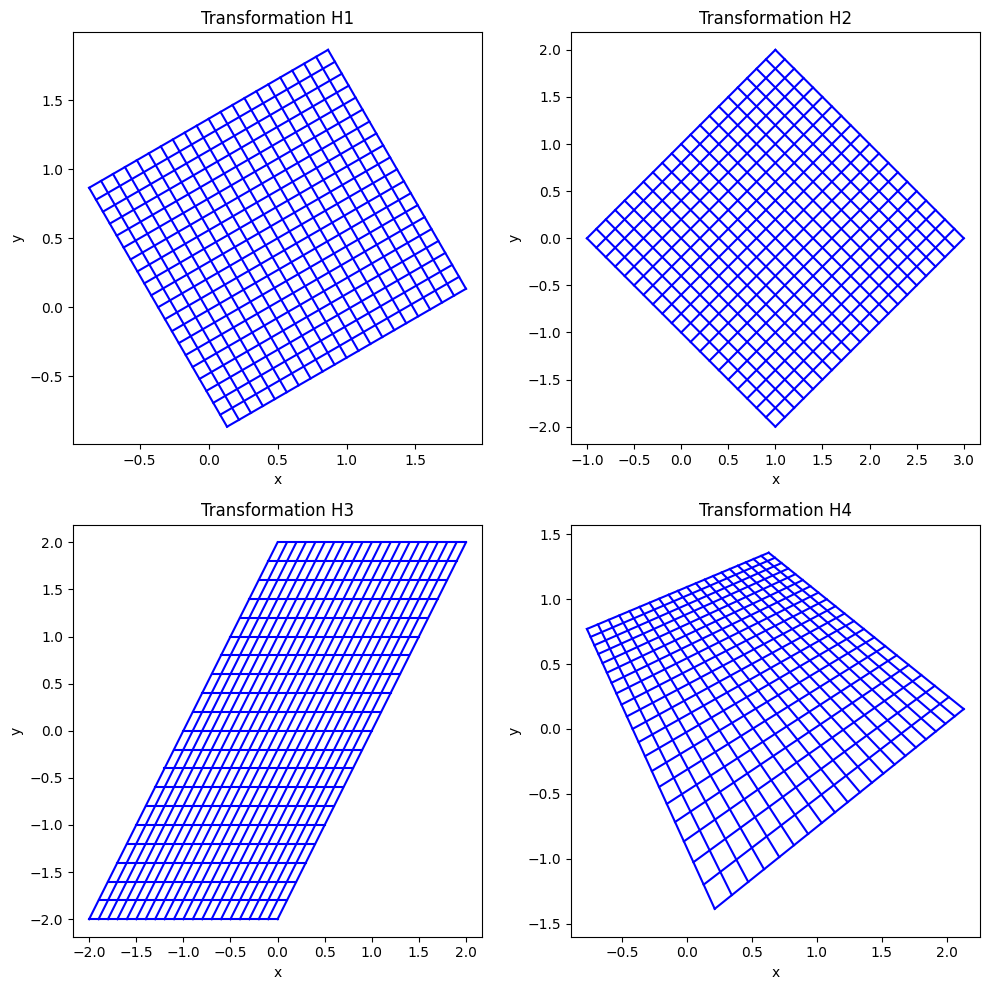

In [12]:
# Build the transformation matrices
H1 = np.array([[np.sqrt(3), -1, 1], [1, np.sqrt(3), 1], [  0,   0, 2]])
H2 = np.array([[1, -1, 1], [1, 1, 0], [0, 0, 1]])
H3 = np.array([[1,  1, 0], [0, 2, 0], [0, 0, 1]])
H4 = np.array([[np.sqrt(3), -1, 1], [1, np.sqrt(3), 1], [1/4, 1/2, 2]])

startpoints_h = np.vstack((startpoints, np.ones(startpoints.shape[1])))
endpoints_h = np.vstack((endpoints, np.ones(endpoints.shape[1])))

print(f'{startpoints_h.shape = }')
print(f'{endpoints_h.shape = }')


H1s, H1e = H1 @ startpoints_h, H1 @ endpoints_h
H2s, H2e = H2 @ startpoints_h, H2 @ endpoints_h
H3s, H3e = H3 @ startpoints_h, H3 @ endpoints_h
H4s, H4e = H4 @ startpoints_h, H4 @ endpoints_h


fig, axes = plt.subplots(2, 2, figsize=(10, 10))

list_zip = zip(axes.flatten(), ['H1', 'H2', 'H3', 'H4'], (H1s, H2s, H3s, H4s), (H1e, H2e, H3e, H4e))

for ax, title, start, end in list_zip:
    start = pflat(start)
    end = pflat(end)
    
    ax.plot([start[0, :], end[0, :]], [start[1, :], end[1, :]], 'b-')
    ax.set(xlabel='x', ylabel='y', title=f'Transformation {title}')
    ax.axis('equal')
    ax.set_title(f'Transformation {title}')

plt.tight_layout()
plt.show()

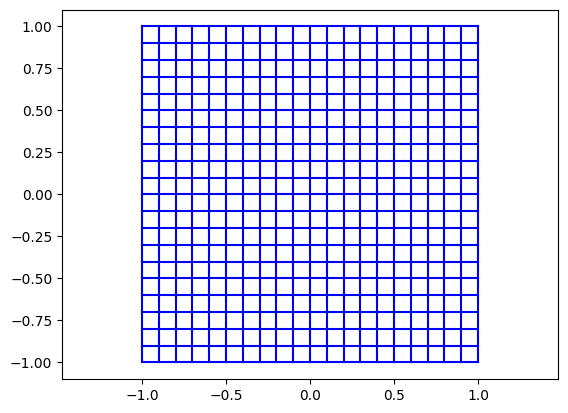

In [13]:
plt.plot([startpoints[0, :], endpoints[0, :]], [startpoints[1, :], endpoints[1, :]], 'b-')
plt.axis('equal')
plt.show()

* Euclidean transformation: H1. Se preservan los angulos y longitudes
* Similarity transformation: H2. Hay escalamiento
* Affine transformation: H3. Conserva el paralelismo entre las líneas rectas y la última fila es 0, 0, 1. Eso quiere decir que la matriz de transformación nace de una matriz nxn, donde n es la dimensión cartesiana.
* Projective transformation: H4. Aquí la última fila de la matriz de transformación no es 0, 0, 1.